In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [2]:
archivo = "histograma_dosis_A_old.out"

xmin, xmax, nx = -0.8, 0.8, 16
ymin, ymax, ny = -1.65, 1.65, 33
zmin, zmax, nz = 98.38, 98.58, 4

factor_dosis = 300
bins_dosis = 30

In [3]:
def centros(a, b, n):
    e = np.linspace(a, b, n + 1)
    c = 0.5 * (e[:-1] + e[1:])
    return e, c

x_edges, x_centros = centros(xmin, xmax, nx)
y_edges, y_centros = centros(ymin, ymax, ny)
z_edges, z_centros = centros(zmin, zmax, nz)

def leer_tdeposit_axis_z(archivo, nx, ny, nz):
    dosis = np.full((nx, ny, nz), np.nan)
    err = np.full((nx, ny, nz), np.nan)

    patron = re.compile(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", re.I)

    ix = None
    iy = None
    iz = 0
    leyendo = False

    with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            m = patron.search(linea)

            if m:
                ix = int(m.group(1)) - 1
                iy = int(m.group(2)) - 1
                iz = 0
                leyendo = False
                continue

            if linea.strip().startswith("#  z-lower") and "proton" in linea.lower():
                iz = 0
                leyendo = True
                continue

            if leyendo:
                partes = linea.split()

                if len(partes) < 4:
                    leyendo = False
                    continue

                try:
                    valor = float(partes[2])
                    error = float(partes[3])
                except ValueError:
                    leyendo = False
                    continue

                if ix is None or iy is None:
                    raise ValueError("No encontré ix/iy antes de la tabla. Revisá el formato del archivo.")

                if 0 <= ix < nx and 0 <= iy < ny and iz < nz:
                    dosis[ix, iy, iz] = valor
                    err[ix, iy, iz] = error
                    iz += 1

    leidos = np.count_nonzero(~np.isnan(dosis))
    esperados = nx * ny * nz

    print("Valores esperados:", esperados)
    print("Valores leídos:", leidos)

    if leidos != esperados:
        print("Ojo: no se leyó la cantidad esperada de vóxeles.")

    return dosis, err

dosis, err_rel = leer_tdeposit_axis_z(archivo, nx, ny, nz)

Valores esperados: 2112
Valores leídos: 2112


In [4]:
X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

x0 = 0.0
y0 = 0.0
rx = 0.8
ry = 1.65

mascara_pouch = ((X - x0) / rx) ** 2 + ((Y - y0) / ry) ** 2 <= 1
mascara_pouch = mascara_pouch & ~np.isnan(dosis)

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[mascara_pouch]
data_err = err_sin_aire[mascara_pouch]
data_dosis_fisica = data_dosis * factor_dosis

print("Vóxeles dentro del pouch:", len(data_dosis_fisica))
print(f"Dosis mínima: {np.min(data_dosis_fisica):.4e}")
print(f"Dosis máxima: {np.max(data_dosis_fisica):.4e}")
print(f"Dosis media: {np.mean(data_dosis_fisica):.4e}")
print(f"Desvío estándar: {np.std(data_dosis_fisica):.4e}")
print(f"Coeficiente de variación: {100 * np.std(data_dosis_fisica) / np.mean(data_dosis_fisica):.2f}%")


Vóxeles dentro del pouch: 1648
Dosis mínima: 0.0000e+00
Dosis máxima: 4.8870e+01
Dosis media: 1.9400e+00
Desvío estándar: 5.1858e+00
Coeficiente de variación: 267.31%


,ix,iy,iz,x,y,z,dosis_Gy_source,dosis_Gy,err_rel
0,1,12,1,-0.75,-0.5,98.405,0.0,0.0,0.0
1,1,12,2,-0.75,-0.5,98.455,0.0,0.0,0.0
2,1,12,3,-0.75,-0.5,98.505,0.0,0.0,0.0
3,1,12,4,-0.75,-0.5,98.555,0.0,0.0,0.0
4,1,13,1,-0.75,-0.4,98.405,0.0,0.0,0.0


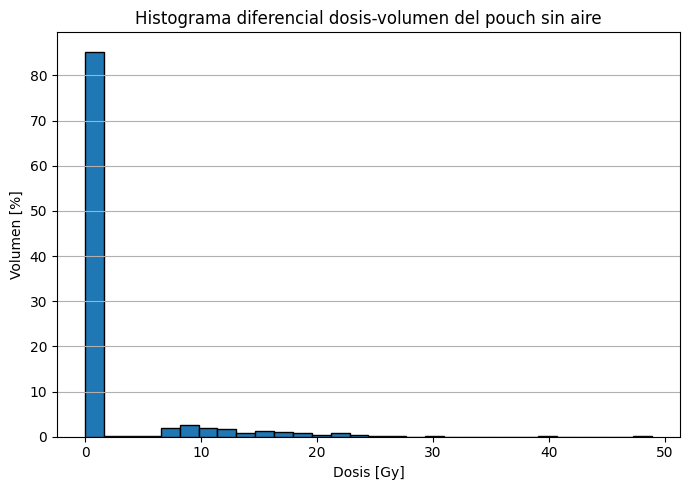

In [ ]:
ix, iy, iz = np.where(mascara_pouch)

df_pouch = pd.DataFrame({
    "ix": ix + 1,
    "iy": iy + 1,
    "iz": iz + 1,
    "x": x_centros[ix],
    "y": y_centros[iy],
    "z": z_centros[iz],
    "dosis_Gy_source": dosis[ix, iy, iz],
    "dosis_Gy": dosis[ix, iy, iz] * factor_dosis,
    "err_rel": err_rel[ix, iy, iz]
})

display(df_pouch.head())

plt.figure(figsize=(7, 5))
plt.hist(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * 100 / len(data_dosis_fisica),
    edgecolor="black"
)
plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen del pouch sin aire")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

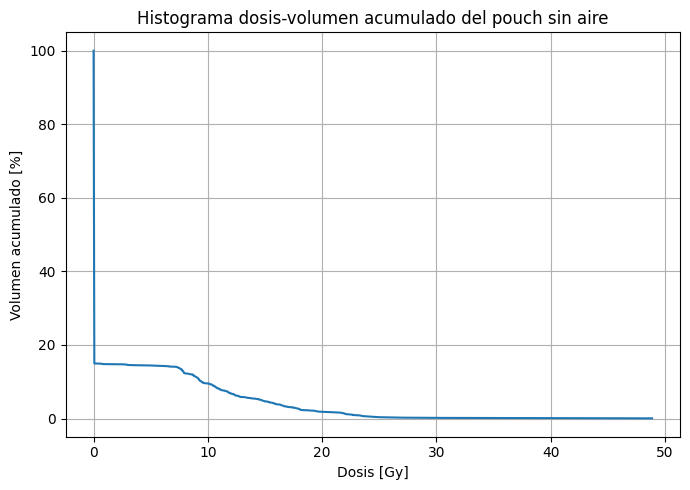

In [6]:
dosis_ordenada = np.sort(data_dosis_fisica)
dosis_unica, indices = np.unique(dosis_ordenada, return_index=True)
vol_acumulado = 100 * (len(dosis_ordenada) - indices) / len(dosis_ordenada)

plt.figure(figsize=(7, 5))
plt.plot(dosis_unica, vol_acumulado)
plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado del pouch sin aire")
plt.grid(True)
plt.tight_layout()
plt.show()


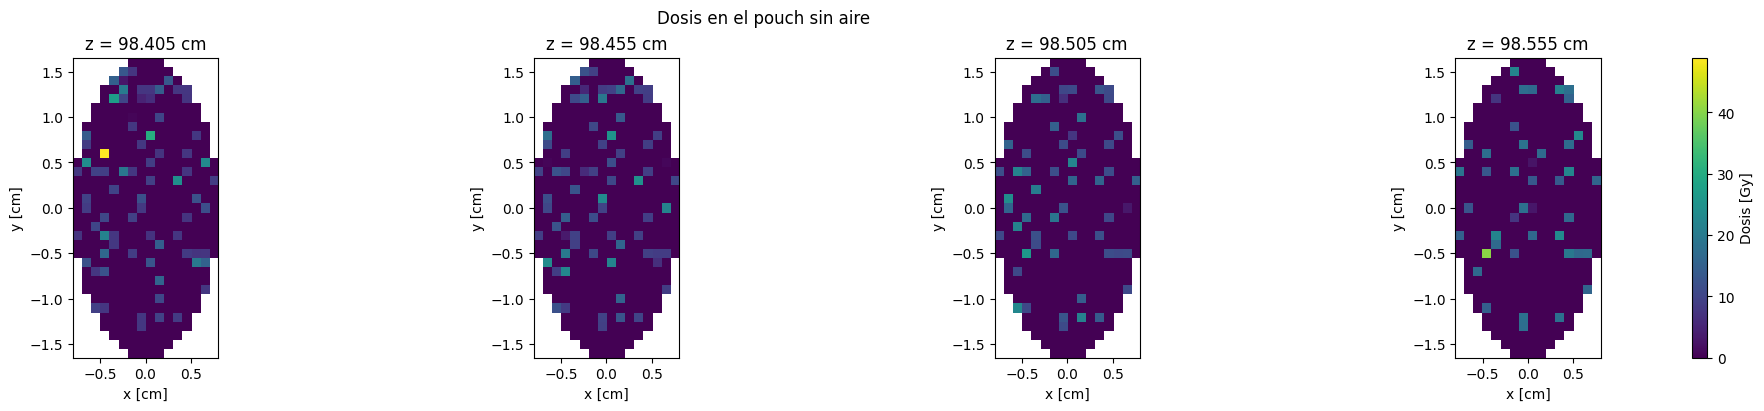

,capa,z_min,z_max,n_voxeles,dosis_min,dosis_max,dosis_media,std,cv_%
0,1,98.38,98.43,412,0.0,48.8700,2.143310,5.368695,250.486173
1,2,98.43,98.48,412,0.0,25.0935,2.026386,4.920106,242.801979
2,3,98.48,98.53,412,0.0,26.3994,1.857044,5.015570,270.083587
3,4,98.53,98.58,412,0.0,40.3560,1.733380,5.411785,312.209869


In [ ]:
fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)
axes = np.atleast_1d(axes)

mapa = dosis_sin_aire * factor_dosis
vmin = np.nanmin(mapa)
vmax = np.nanmax(mapa)

for k in range(nz):
    im = axes[k].imshow(
        mapa[:, :, k].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[k].set_xlabel("x [cm]")
    axes[k].set_ylabel("y [cm]")
    axes[k].set_title(f"z = {z_centros[k]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy]")
plt.suptitle("Dosis en el pouch sin aire")
plt.show()

resumen_capas = []

for k in range(nz):
    datos_capa = mapa[:, :, k][mascara_pouch[:, :, k]]

    if len(datos_capa) == 0:
        continue

    resumen_capas.append({
        "capa": k + 1,
        "z_min": z_edges[k],
        "z_max": z_edges[k + 1],
        "n_voxeles": len(datos_capa),
        "dosis_min": np.min(datos_capa),
        "dosis_max": np.max(datos_capa),
        "dosis_media": np.mean(datos_capa),
        "std": np.std(datos_capa),
        "cv_%": 100 * np.std(datos_capa) / np.mean(datos_capa)
    })

df_capas = pd.DataFrame(resumen_capas)
display(df_capas)